<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path
from datetime import datetime

from scipy.integrate import odeint
from posterior_plot import plot_posterior_kde_grid

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p\\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

In [3]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    C = state[4*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma[i] * E[i]
        dI[i] =  sigma[i] * E[i] - gamma[i] * I[i]
        dR[i] =  gamma[i] * I[i]
        dC[i] = sigma[i] * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dC.flatten()])


# Define Parameters

In [4]:
7*53

371

In [5]:
n_regions = 3 
T = 53  #371/7 #96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N = np.array([1100000, 440000, 680000])
## Get the Parameters
beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/6)*7     # 1/infectious period per week (Ebola: ~7 days)

sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

# Initial conditions
E0 = np.array([10, 1, 1])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
C0 = np.array([10,10,10])
S0 = np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), C0.flatten()])


# Solve the ODEs

In [6]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma, N))

## Get the New Infections and Deaths

In [7]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
C_total = sol[:, 4*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

## Show New infections

In [8]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.32355506e+01, 8.61571422e+00, 7.11411465e+00],
       [2.39320184e+01, 2.08455024e+01, 1.48136042e+01],
       [4.06176794e+01, 3.91927341e+01, 2.34083205e+01],
       [6.86493372e+01, 7.29629589e+01, 3.65196204e+01],
       [1.15992609e+02, 1.35767452e+02, 5.69352346e+01],
       [1.95979193e+02, 2.52614738e+02, 8.87595891e+01],
       [3.31115241e+02, 4.69981985e+02, 1.38369851e+02],
       [5.59411875e+02, 8.74236891e+02, 2.15703179e+02],
       [9.45052727e+02, 1.62569207e+03, 3.36243851e+02],
       [1.59636739e+03, 3.02126964e+03, 5.24113379e+02],
       [2.69605866e+03, 5.60869083e+03, 8.16872349e+02],
       [4.55187368e+03, 1.03906981e+04, 1.27296885e+03],
       [7.68107726e+03, 1.91771460e+04, 1.98325932e+03],
       [1.29499437e+04, 3.51477782e+04, 3.08874866e+03],
       [2.18003205e+04, 6.36057200e+04, 4.80771354e+03],
       [3.66069407e+04, 1.12514154e+05, 7.47670427e+03],
       [6.12109504e+04, 1.91299

## Add Noise

In [9]:
from add_noise import Add_noise

observed_cases = Add_noise(Infections, reporting_rate= reporting_rate, phi=phi, seed=0)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [10]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
}

raw = pd.DataFrame(data)
raw.to_csv('Data/synthetic_dataset_no_coupling.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149998e+07,10.000000,10.000000,0.000000,10.000000,0.000000,0,4.499989e+06,...,10.000000,0.000000,0,6.799989e+06,1.000000,10.000000,0.000000,10.000000,0.000000,0
1,2013-12-29,1,1.149996e+07,21.454664,14.091001,9.144550,23.235551,13.235551,8,4.499964e+06,...,18.615714,8.615714,12,6.799969e+06,13.535588,7.757085,9.357030,17.114115,7.114115,9
2,2013-12-30,2,1.149992e+07,36.777877,23.483964,23.683605,47.167569,23.932018,26,4.499927e+06,...,39.461217,20.845502,30,6.799946e+06,22.112342,11.432354,20.495365,31.927719,14.813604,9
3,2013-12-31,3,1.149985e+07,62.201753,39.641559,48.143690,87.785248,40.617679,27,4.499859e+06,...,78.653951,39.192734,26,6.799910e+06,34.558063,17.767141,37.568899,55.336039,23.408321,31
4,2014-01-01,4,1.149974e+07,105.103904,66.974791,89.459795,156.434586,68.649337,68,4.499732e+06,...,151.616910,72.962959,75,6.799854e+06,53.882403,27.693938,64.161722,91.855660,36.519620,27


# Plot the results

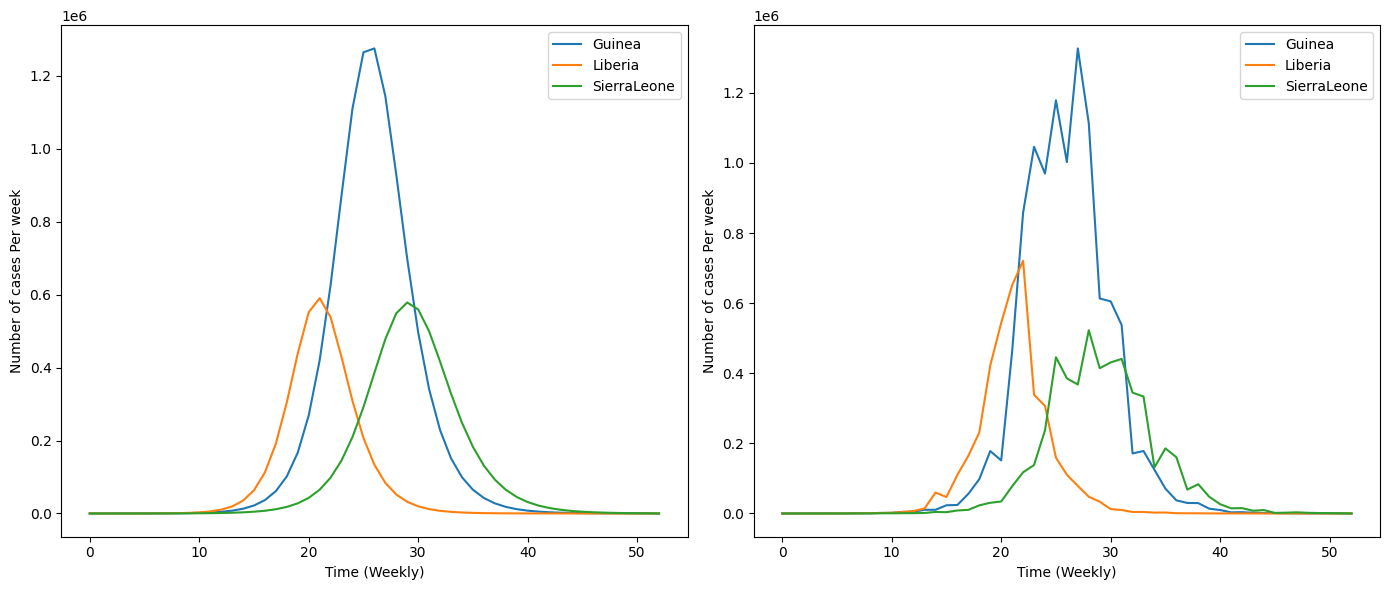

In [11]:
fig, ax = plt.subplots(1,2, figsize = (14, 6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    # ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    # ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    # ax[2].plot(raw[f'C_{countries[i]}'])
    # ax[2].legend(countries)
    # ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    # ax[2].set_xlabel('Time (Weekly)')
    # ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.savefig('images/generated_no_coupling.pdf')
plt.show()

In [12]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Removed', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

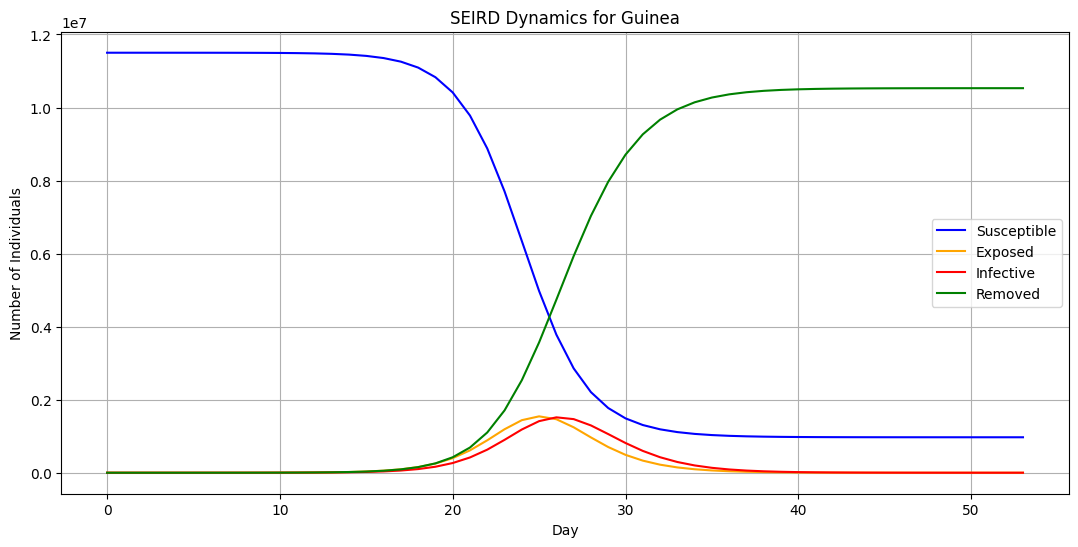

In [13]:
plot_SEIR(raw, 'Guinea')

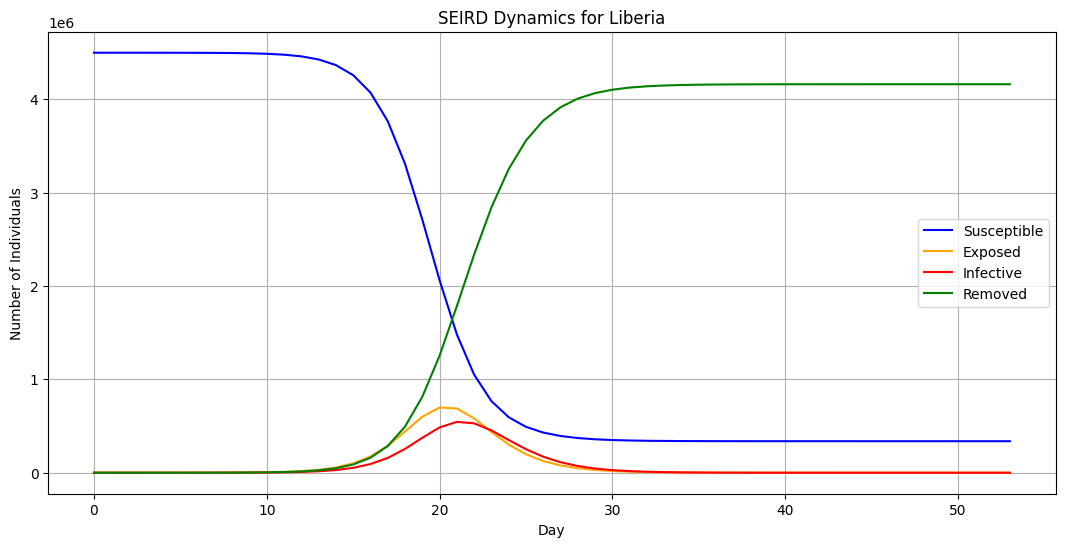

In [14]:
plot_SEIR(raw, 'Liberia')

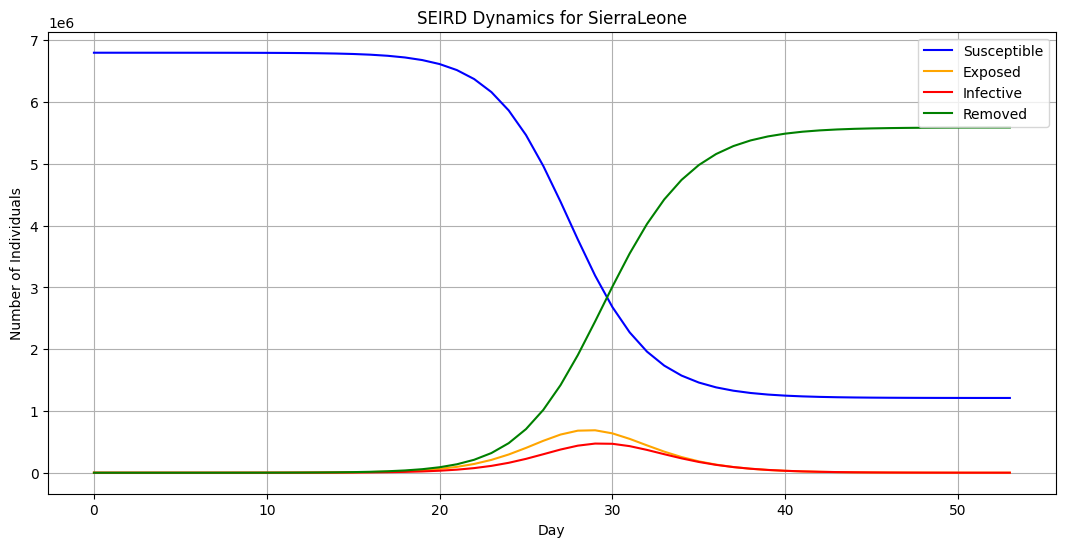

In [15]:
plot_SEIR(raw, 'SierraLeone')

# Create a function to plot Posterior for Parameters

# Fit the Model to daily cases


In [16]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases1 = raw['Guinea_Noise']
weekly_cases2 = raw['Liberia_Noise']
weekly_cases3 = raw['SierraLeone_Noise']

cases1 = weekly_cases1.values  # Shape: (T, 3)
cases2 = weekly_cases2.values  # Shape: (T, 3)
cases3 = weekly_cases3.values  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6])

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/6)*7 
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 

# Define initial conditions
i0 = [10, 10, 10]
e0 = [10, 1, 1]
s0 = N - i0 - e0
r0 = [0, 0, 0]
c0 = [10, 10, 10]
y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [73]:

# Make the data struture
seir_data1 = {
    "n_days": len(cases1),
    "y0": y1,
    "t0": 0,
    "t": np.arange(1, len(cases1)+1),
    "N": int(N[0]),
    "cases": cases1,
    'beta_value': beta[0],
    'sigma_value': sigma[0],
    'gamma_value': gamma[0],
    "reporting_rate": reporting_rate
}

seir_data2 = {
    "n_days": len(cases2),
    "y0": y2,
    "t0": 0,
    "t": np.arange(1, len(cases2)+1),
    "N": int(N[1]),
    "cases": cases2,
    'beta_value': beta[1],
    'sigma_value': sigma[1],
    'gamma_value': gamma[1],
    "reporting_rate": reporting_rate
}
seir_data3 = {
    "n_days": len(cases3),
    "y0": y3,
    "t0": 0,
    "t": np.arange(1, len(cases3)+1),
    "N": int(N[2]),
    "cases": cases3,
    'beta_value': beta[2],
    'sigma_value': sigma[2],
    'gamma_value': gamma[2],
    "reporting_rate": reporting_rate
}

seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
seir_incidence_model3 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')

In [74]:
# %run fit_single.py
fit1 = seir_incidence_model1.sample(data = seir_data1,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the fit output with a memorable name
output_dir = f'outputs/Guinea_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit1.save_csvfiles(dir=output_dir)
print(f"\nFit for Guinea saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits for Guinea completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 03:56 Iteration: 1900 / 2000 [ 95%]  (Sampling)

































































chain 1 |██████████| 16:48 Sampling completed                       
chain 2 |██████████| 16:48 Sampling completed                       
chain 3 |██████████| 16:48 Sampling completed                       
chain 4 |██████████| 16:48 Sampling completed                       

                                                                                                                                                                                                                                                                                                                                

Fit for Guinea saved to: outputs/Guinea_20250608_102056
Fits for Guinea completed. Check 'output/' directory.


In [75]:
# %run fit_single.py
fit2 = seir_incidence_model2.sample(data = seir_data2,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the fit output with a memorable name
output_dir = f'outputs/Liberia_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit2.save_csvfiles(dir=output_dir)
print(f"\nFit Liberia saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits Liberia completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 04:39 Iteration: 1900 / 2000 [ 95%]  (Sampling)

































































chain 1 |██████████| 27:13 Sampling completed                       
chain 2 |██████████| 27:13 Sampling completed                       
chain 3 |██████████| 27:13 Sampling completed                       
chain 4 |██████████| 27:13 Sampling completed                       



Fit Liberia saved to: outputs/Liberia_20250608_104858
Fits Liberia completed. Check 'output/' directory.


In [76]:
# %run fit_single.py
fit3 = seir_incidence_model3.sample(data = seir_data3,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')  # e.g., 20250607_103939

# Save the fit output with a memorable name
output_dir = f'outputs/Sierraleone_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit3.save_csvfiles(dir=output_dir)
print(f"\nFit Sierra Leone saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits Sierra Leone completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 05:13 Iteration: 1900 / 2000 [ 95%]  (Sampling)






























































chain 1 |██████████| 21:17 Sampling completed                       
chain 2 |██████████| 21:17 Sampling completed                       
chain 3 |██████████| 21:17 Sampling completed                       
chain 4 |██████████| 21:17 Sampling completed                       



Fit Sierra Leone saved to: outputs/Sierraleone_20250608_111426
Fits Sierra Leone completed. Check 'output/' directory.


In [25]:
from cmdstanpy import from_csv

# Load Guinea fit
fit1 = from_csv('outputs/Guinea_20250608_102056/simple_seir-*_*.csv')
print("Guinea fit loaded")

# Load Liberia fit
fit2 = from_csv('outputs/Liberia_20250608_104858/simple_seir-*_*.csv')
# fit2 = from_csv('outputs/liberia_20250608_055540/simple_seir-*_*.csv')
print("Liberia fit loaded")

# # Load Sierra Leone fit
# fit3 = from_csv('outputs/sierraleone_20250608_060434/simple_seir-*_*.csv')
fit3 = from_csv('outputs/Sierraleone_20250608_111426/simple_seir-*_*.csv')
print("Sierra Leone fit loaded")

Guinea fit loaded
Liberia fit loaded
Sierra Leone fit loaded


In [78]:
print(fit3.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
63 of 1000 (6.30%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



In [79]:
fit1_summary = fit1.summary()
fit1_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.833471,0.002771,0.121204,0.115234,0.659229,0.821025,1.060240,2074.92,1565.79,1.00064
beta,2.127330,0.004967,0.197244,0.192597,1.836110,2.111810,2.476000,1695.71,1728.89,1.00048
gamma,0.806611,0.003488,0.132350,0.127826,0.610403,0.792776,1.037370,1481.75,1714.72,1.00312
recovery_time,1.272520,0.005333,0.205311,0.203457,0.963983,1.261390,1.638270,1481.73,1714.72,1.00258
incubation_period,1.224330,0.003748,0.172107,0.172619,0.943177,1.217990,1.516920,2074.93,1565.79,1.00064
R0,2.677000,0.007174,0.296455,0.287513,2.235850,2.647150,3.224080,1704.49,1700.74,1.00090
phi,4.762720,0.022663,1.110340,1.105630,3.153790,4.671230,6.692600,2475.57,1960.38,1.00008
phi_inv,0.221536,0.001056,0.052273,0.050271,0.149419,0.214077,0.317079,2475.57,1960.38,1.00042


In [80]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,1.030230,0.003472,0.148230,0.137012,0.826168,1.011320,1.309160,1953.87,1871.56,1.00155
beta,2.480060,0.005861,0.231458,0.220685,2.146740,2.455900,2.891150,1636.33,1635.81,1.00061
gamma,0.978627,0.003919,0.160913,0.149793,0.750739,0.957521,1.275680,1775.38,1707.49,1.00051
recovery_time,1.048420,0.003910,0.165815,0.163798,0.783899,1.044360,1.332020,1775.39,1707.49,1.00030
incubation_period,0.989702,0.003078,0.135157,0.136142,0.763852,0.988804,1.210410,1953.89,1871.56,1.00165
R0,2.570110,0.005989,0.265623,0.265452,2.162810,2.555400,3.026830,1948.74,1861.42,1.00126
phi,6.054660,0.029590,1.414740,1.343180,3.978390,5.898460,8.573260,2245.77,2192.80,1.00244
phi_inv,0.174568,0.000910,0.042821,0.038677,0.116641,0.169536,0.251358,2245.75,2192.80,1.00244


In [81]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.870159,0.004118,0.174429,0.159436,0.627747,0.846126,1.198030,1997.84,1659.57,1.00063
beta,2.214610,0.009401,0.348953,0.330190,1.714100,2.169550,2.841820,1444.76,1468.99,1.00114
gamma,1.027620,0.006420,0.236118,0.223565,0.694882,1.001240,1.457550,1449.57,1135.78,1.00070
recovery_time,1.023920,0.005945,0.232550,0.224017,0.686080,0.998756,1.439100,1449.57,1135.78,1.00062
incubation_period,1.193410,0.005074,0.228932,0.225874,0.834703,1.181860,1.592990,1997.86,1659.57,1.00043
R0,2.199940,0.006295,0.266532,0.250559,1.828540,2.164200,2.700910,1755.04,1585.59,1.00010
phi,3.459360,0.016409,0.756423,0.721077,2.314070,3.388300,4.823030,2146.76,1733.89,1.00115
phi_inv,0.303351,0.001504,0.068470,0.063433,0.207338,0.295134,0.432138,2146.75,1733.89,1.00183


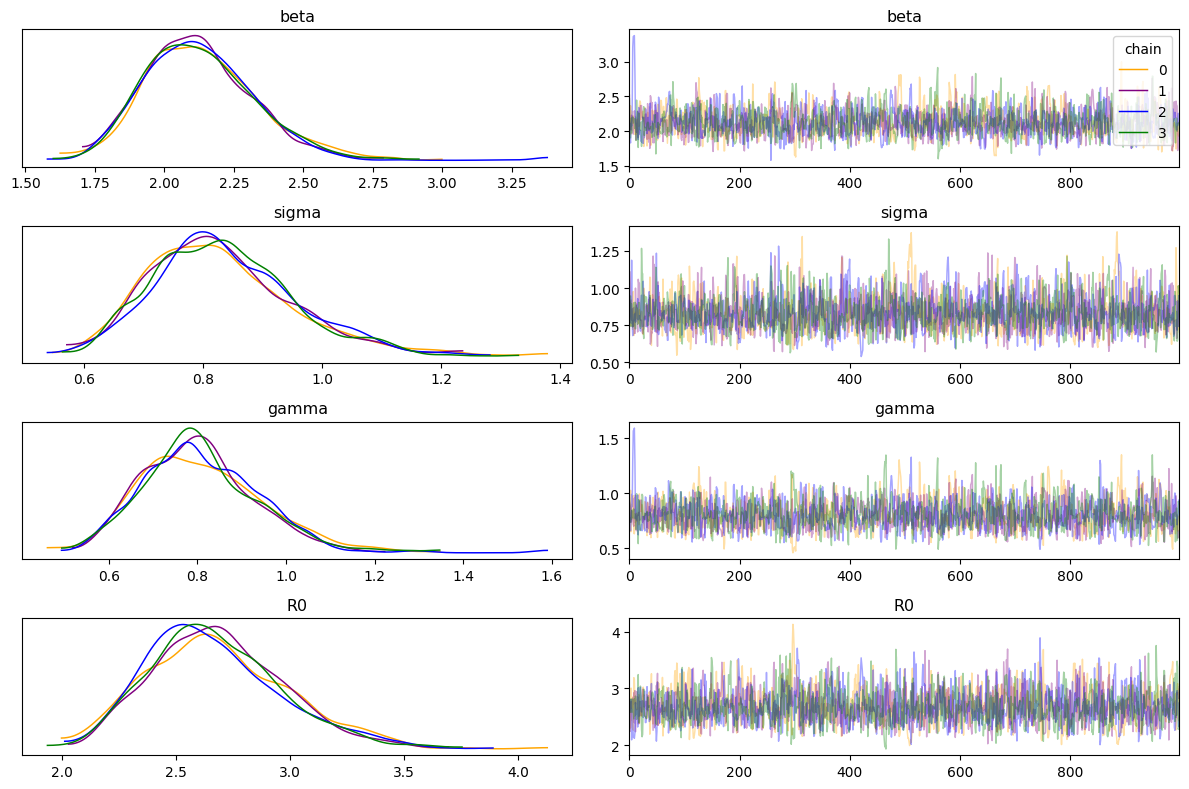

In [82]:
## trace plots
axes = az.plot_trace(fit1, 
              var_names=["beta", "sigma", "gamma", "R0"],
            #   figsize=(12, 8),
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

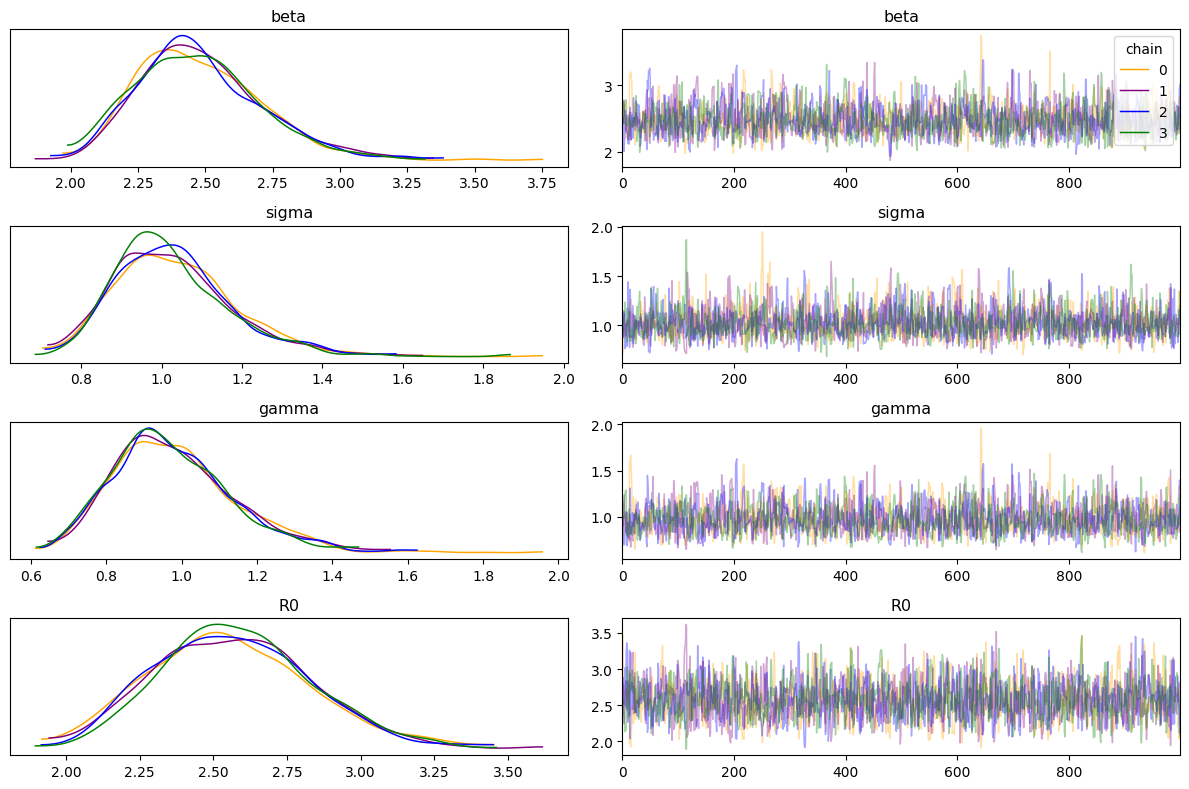

In [83]:
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

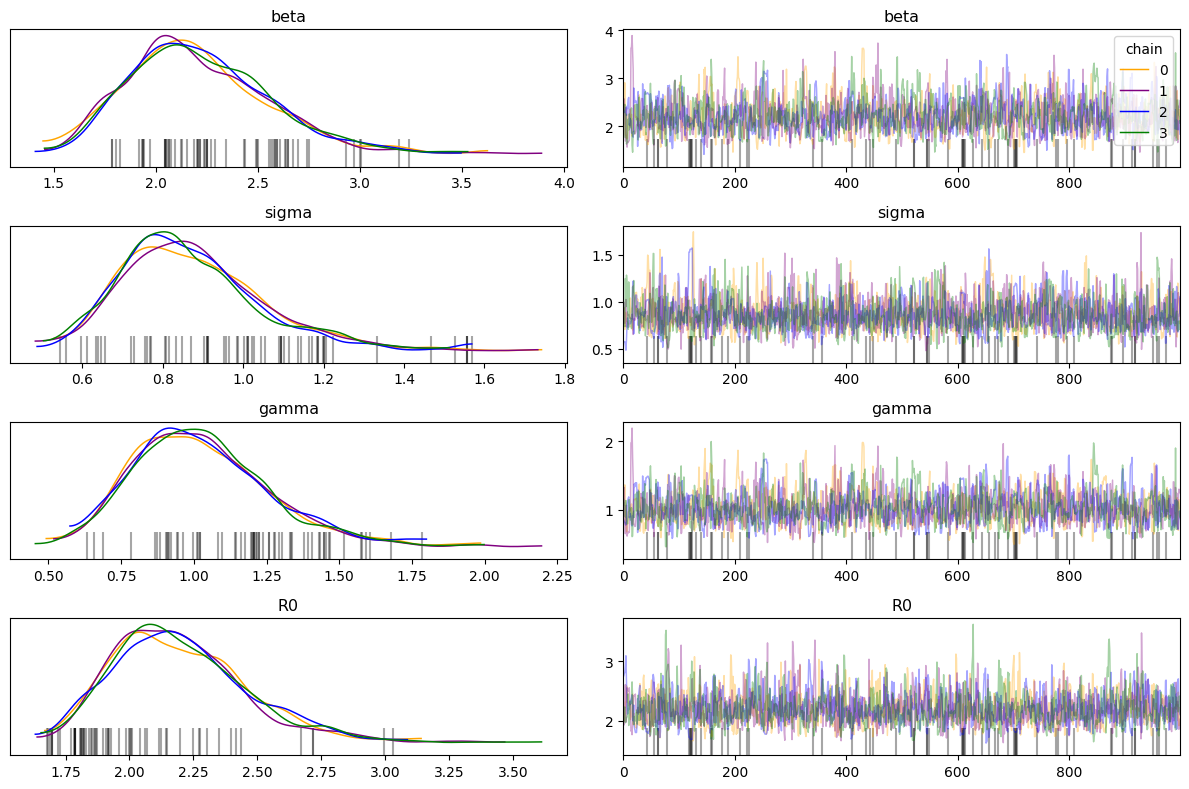

In [84]:
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

In [ ]:
# Extract posterior samples
# post_guinea = fit1.draws_pd()
# post_liberia = fit2.draws_pd()
# post_sierra = fit3.draws_pd()

# ## save the posterior samples
# post_guinea.to_csv('./Data/posterior_samples_guinea.csv', index=False)
# post_liberia.to_csv('./Data/posterior_samples_liberia.csv', index=False)
# post_sierra.to_csv('./Data/posterior_samples_sierra.csv', index=False)

# Posterior Predictive Checks

In [86]:
# fit1_summary.filter(like="pred_incidence", axis=0)

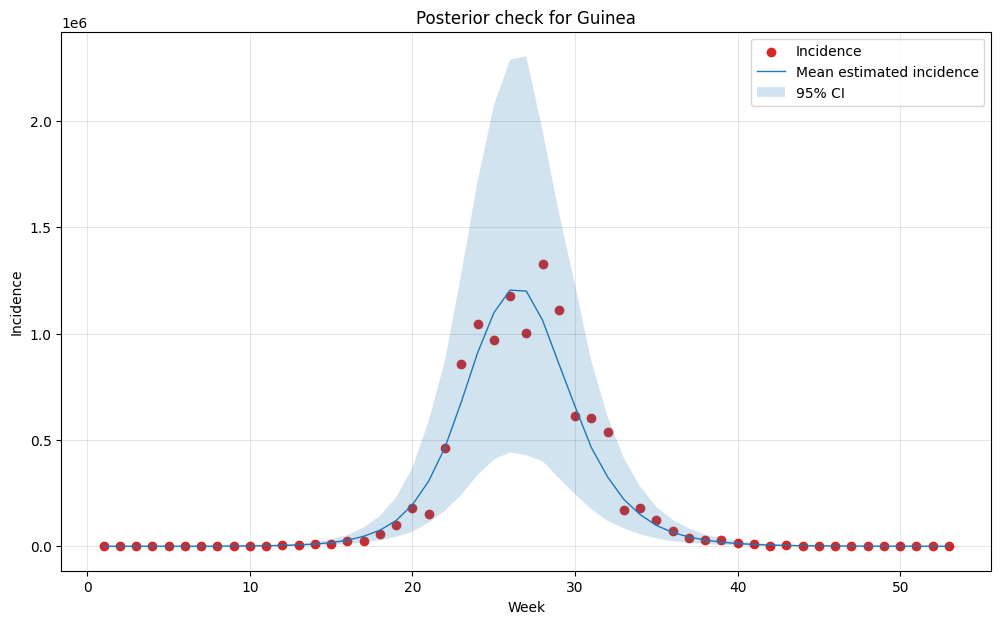

In [87]:
post_pred1 = pd.DataFrame(fit1_summary.filter(like="pred_incidence", axis=0))
post_pred1["t"] = range(1, T+1)
post_pred1["incidence"] = list(cases1)
post_pred1 = post_pred1.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Guinea')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred1.index, y = post_pred1.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred1.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred1.index, y1 = post_pred1['5%'], y2 = post_pred1['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

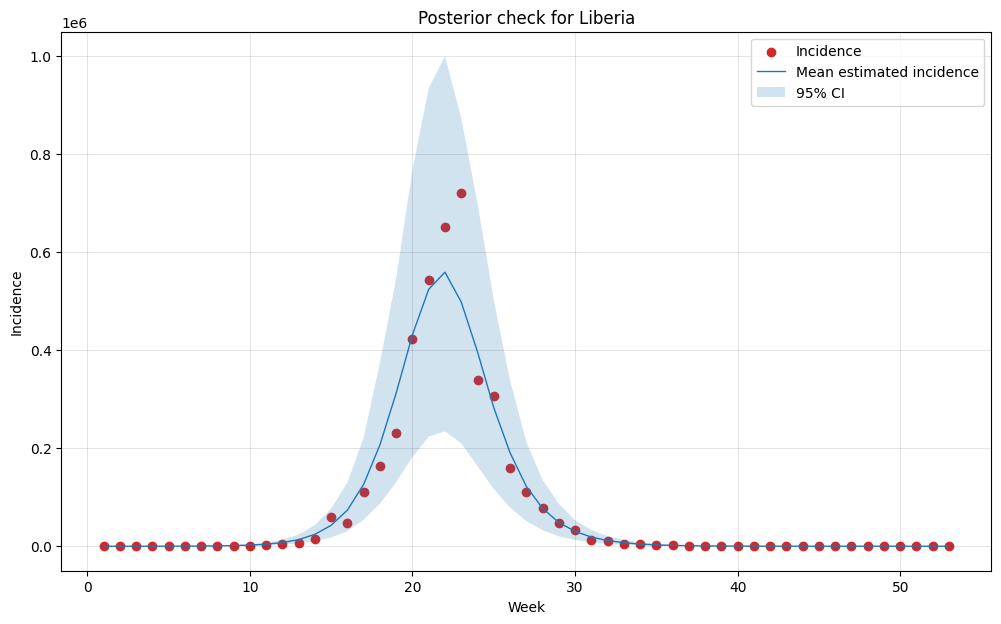

In [88]:
post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
post_pred2["t"] = range(1, T+1)
post_pred2["incidence"] = list(cases2)
post_pred2 = post_pred2.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Liberia')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

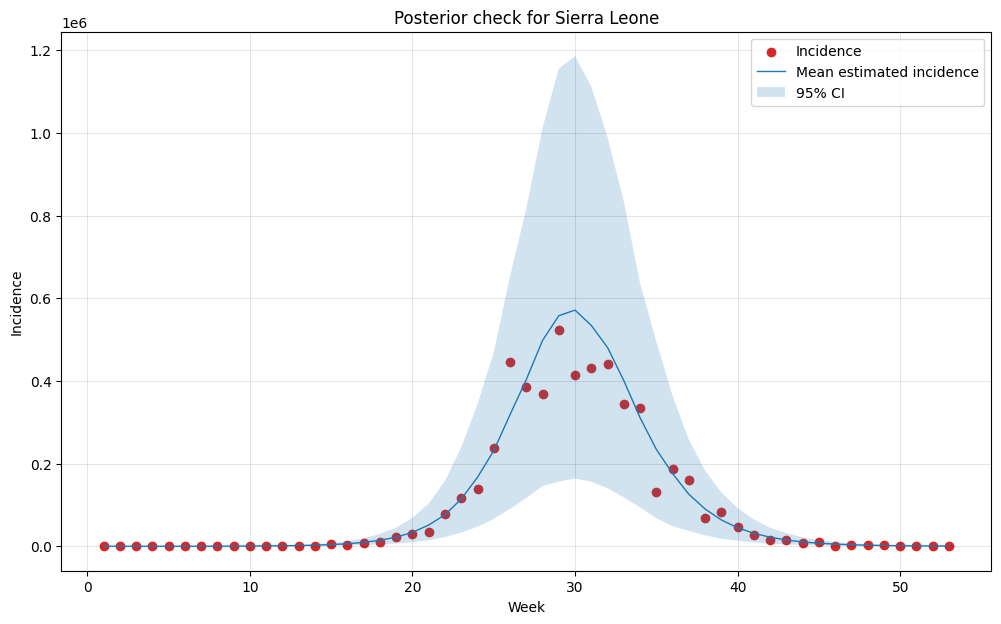

In [89]:
post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
post_pred3["t"] = range(1, T+1)
post_pred3["incidence"] = list(cases3)
post_pred3 = post_pred3.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Sierra Leone')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

In [26]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/6)*7 
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma[0], 'gamma': gamma[0], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec[0],
    'incubation_period': incu[0]}

t2 = {'beta':beta[1],'sigma': sigma[1], 'gamma': gamma[1], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec[1],
    'incubation_period': incu[1]}

t3 = {'beta':beta[2],'sigma': sigma[2], 'gamma': gamma[2], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[2], 'recovery_time':rec[2],
    'incubation_period': incu[2]}

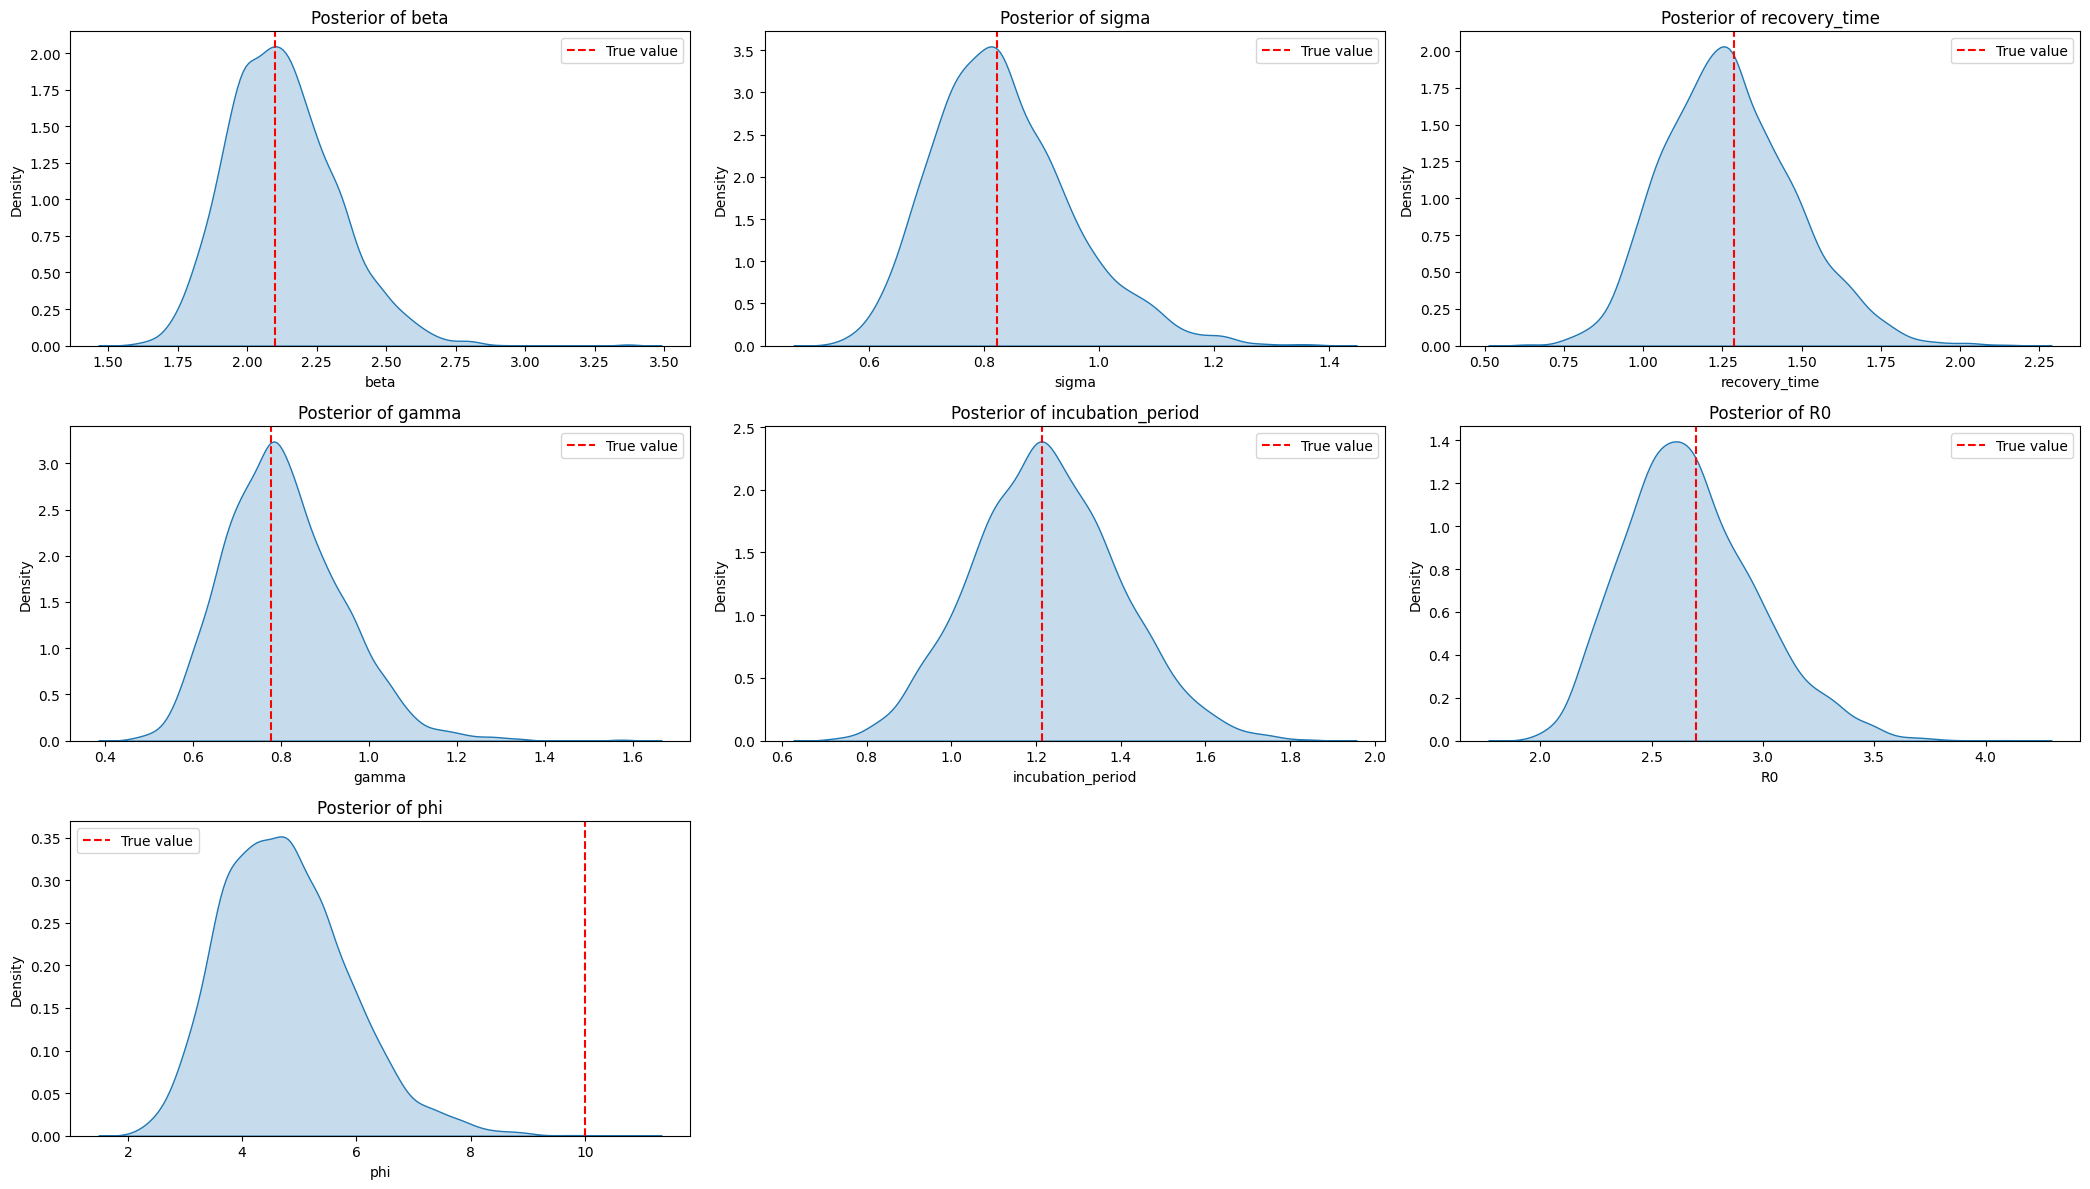

In [27]:
from posterior_plot import plot_posterior_kde_grid

plot_posterior_kde_grid(fit1, parameters1, 3,t1)

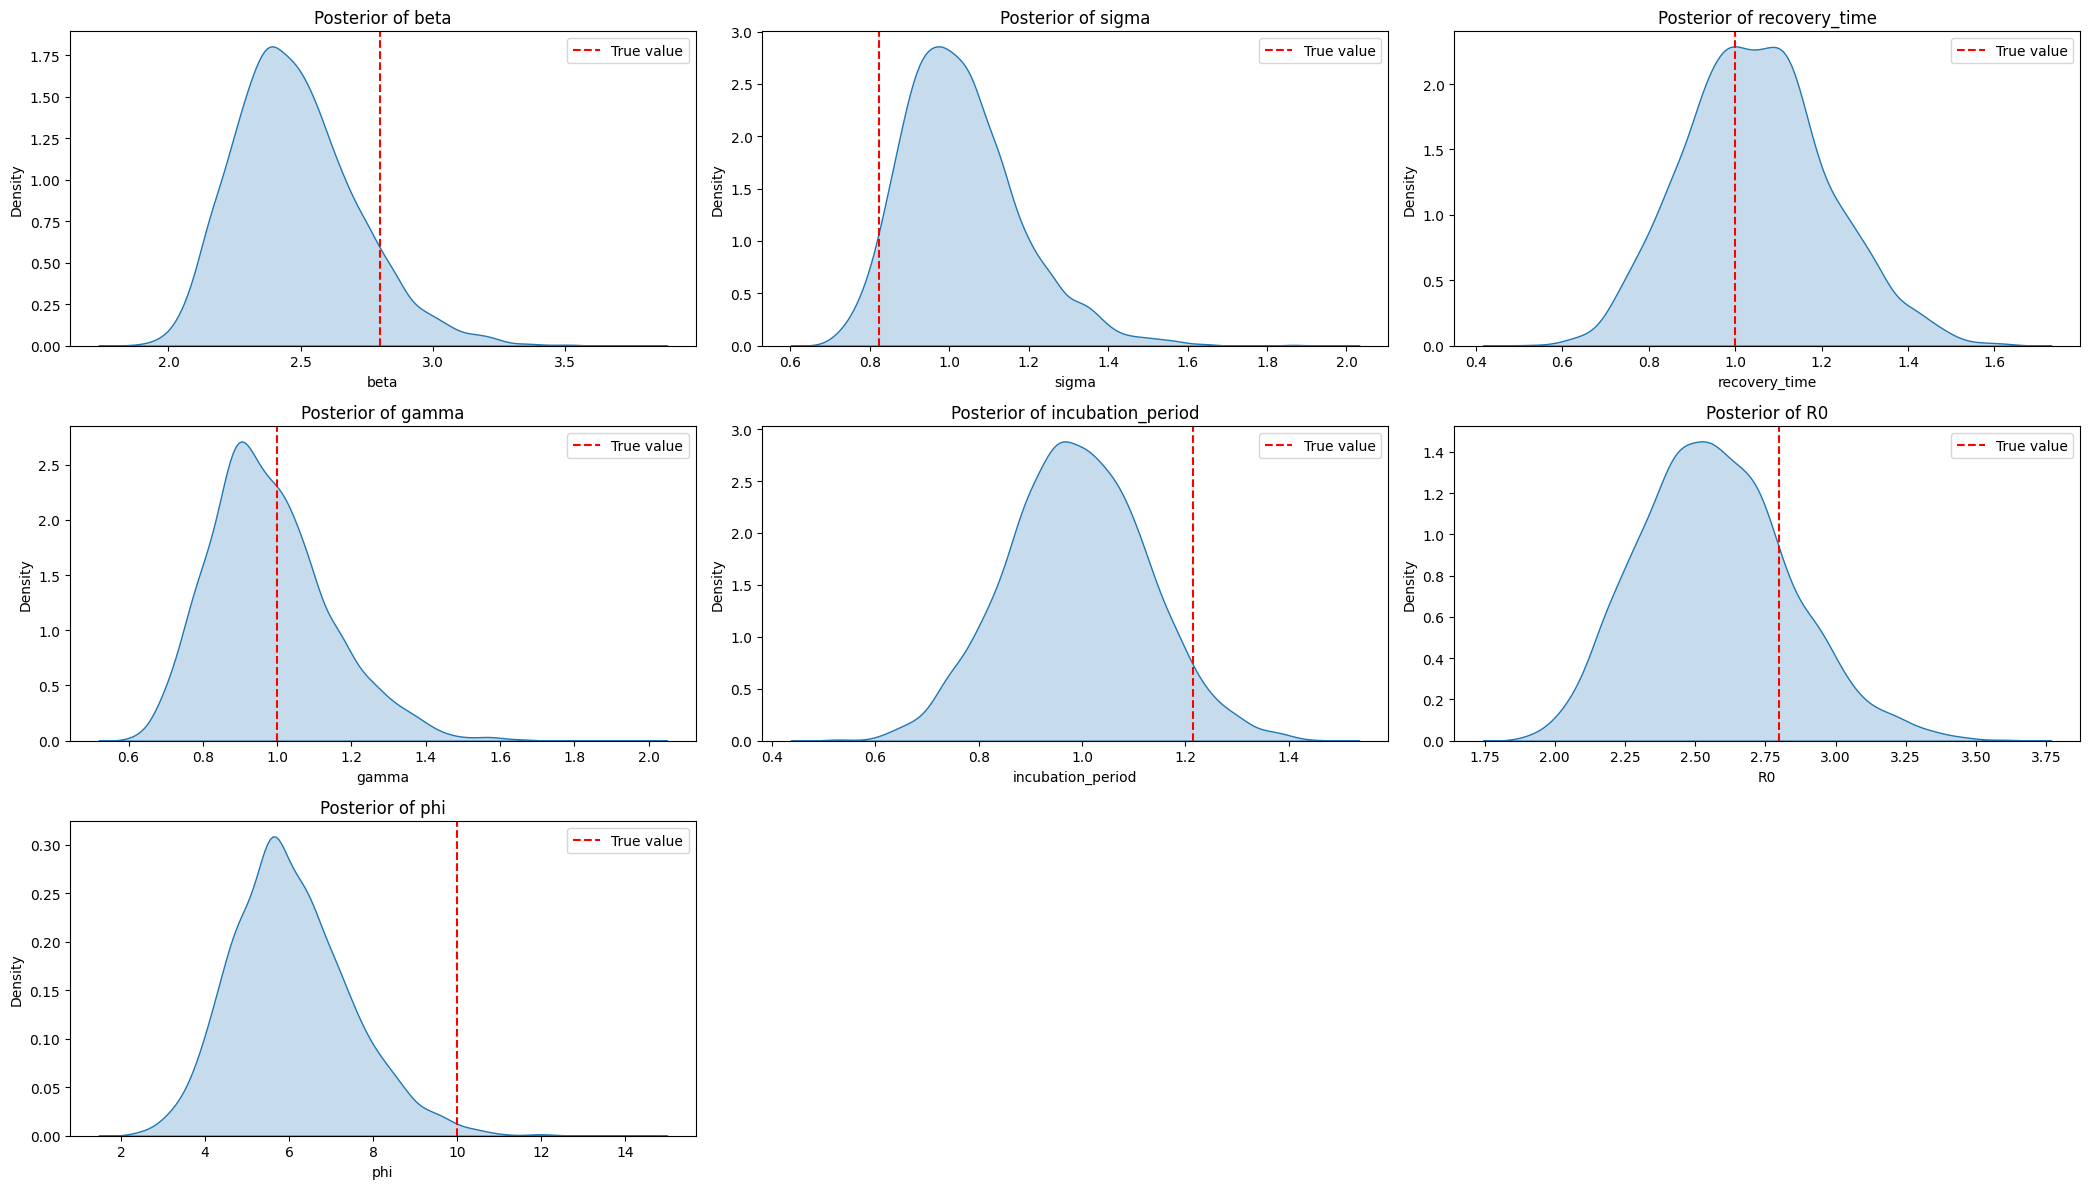

In [28]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2)

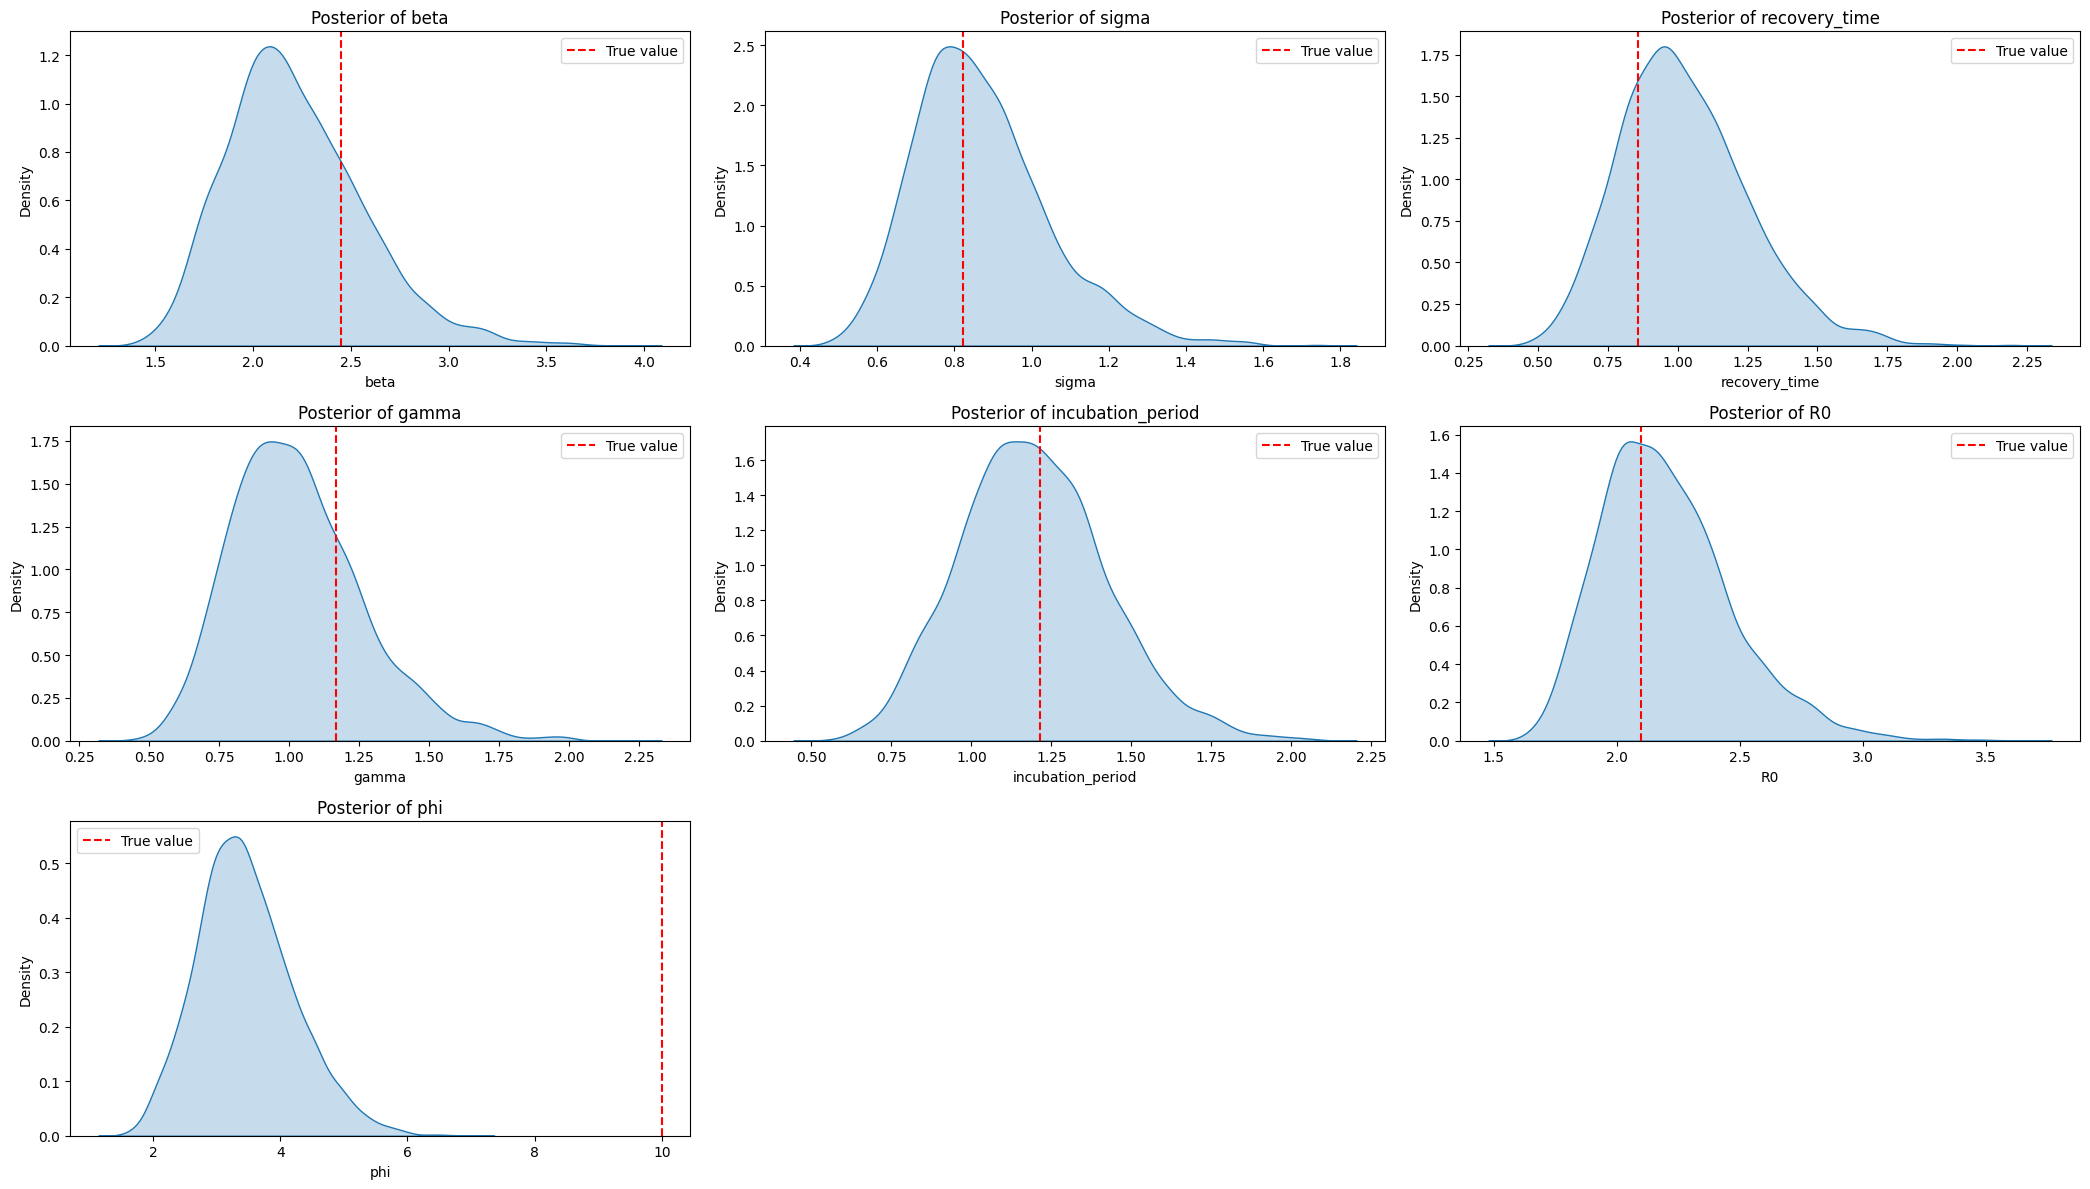

In [29]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3)

## Plot SEIR Compartments

In [32]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 6))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

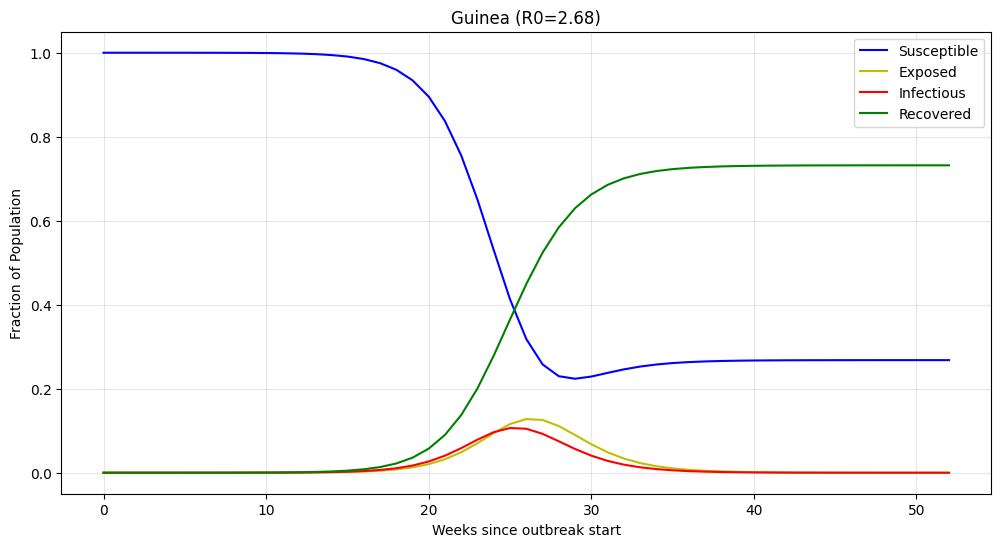

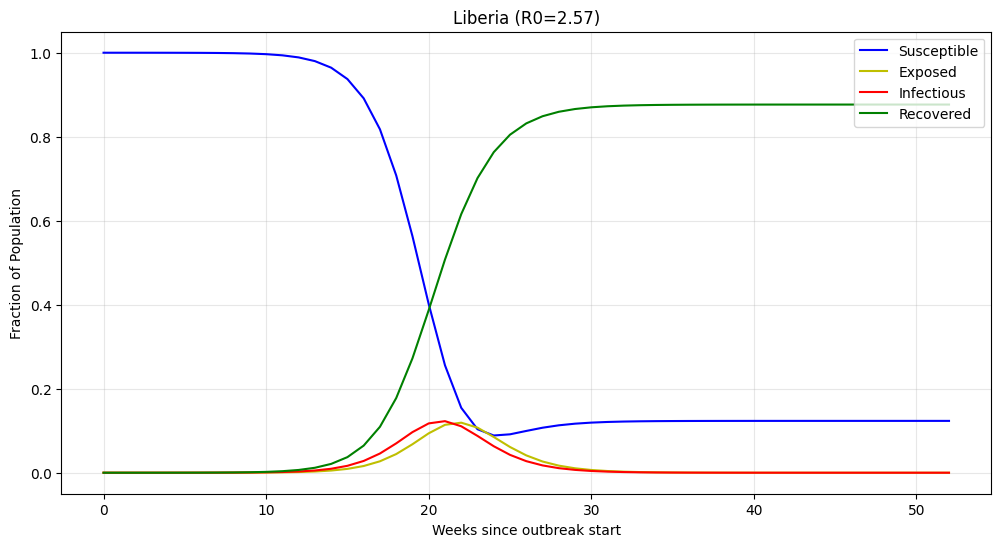

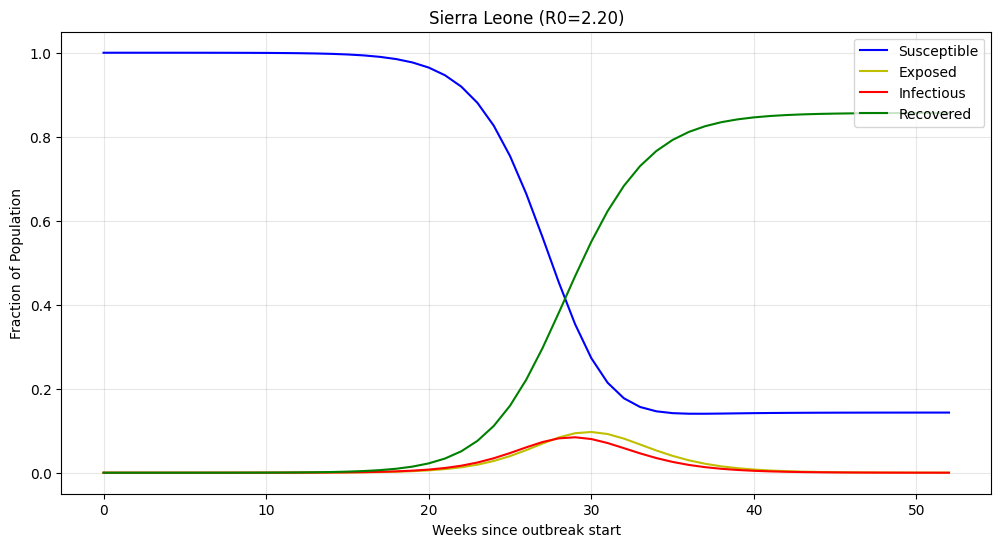

In [33]:
plot_compartment(fit1, country_idx=0)
plot_compartment(fit2, country_idx=1)
plot_compartment(fit3, country_idx=2)

# FITTING FOR 3 PATCHES

In [32]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.tail()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
91,0,0,0
92,0,0,0
93,0,0,0
94,0,0,0
95,0,0,0


In [17]:
%run fit_multi.py

Running model fit for All Patches at time 20250608_141229...

Done compiling...Now Sampling!


chain 1 |          | 00:00 Status


chain 1 |▍         | 00:39 Status






















chain 1 |▉         | 07:08 Iteration:    1 / 2000 [  0%]  (Warmup)





















chain 1 |█▎        | 14:06 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 20:27 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 26:40 Iteration:  300 / 2000 [ 15%]  (Warmup)

chain 1 |██▋       | 33:10 Iteration:  400 / 2000 [ 20%]  (Warmup)
chain 1 |███▏      | 39:31 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 45:42 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 51:46 Iteration:  700 / 2000 [ 35%]  (Warmup)
chain 1 |████▌     | 58:00 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 1:04:22 Iteration: 1000 / 2000 [ 50%]  (Warmup)
chain 1 |█████▉    | 1:10:31 Iteration: 1001 / 2000 [ 50%]  (Sampling)

chain 1 |██████▎   | 1:16:41 Iteration: 1100 / 2000 [ 55%]  (Sampling)
chain 1 |██████▊   | 1:22:56 Iteration: 1200 / 2000 [ 60%]  (Sampl



Fit for all Patches saved to: outputs/all_Patches_20250608_141229
Fits for all Patches completed. Check 'output/' directory.


In [34]:
from cmdstanpy import from_csv

# Load Guinea fit
fit_multi_model = from_csv('outputs/all_Patches_20250608_213025/mult-*_*.csv')
print("All fit loaded")
print(fit_multi_model.diagnose())

All fit loaded
Checking sampler transitions treedepth.
3000 of 1000 (300.00%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
1000 of 1000 (100.00%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.00, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all paramet

In [35]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", 
                               "sigma", "gamma", "recovery_time", 
                                "R0[1]","R0[2]", "R0[3]", 
                               "incubation_period", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],2.073290,NaN,2.009840,1.537990,0.207770,1.405690,5.27401,NaN,NaN,NaN
beta[2],0.752557,NaN,0.506076,0.687995,0.158561,0.728170,1.39533,NaN,NaN,NaN
beta[3],1.653350,NaN,1.517360,1.011500,0.380126,1.067160,4.09895,NaN,NaN,NaN
R0[1],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R0[2],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R0[3],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phi,1.938780,NaN,2.531010,0.712687,0.000010,0.736411,6.28230,NaN,NaN,NaN
phi_inv,25000.800000,NaN,43306.200000,1.331530,0.159177,1.497760,100000.00000,NaN,NaN,NaN


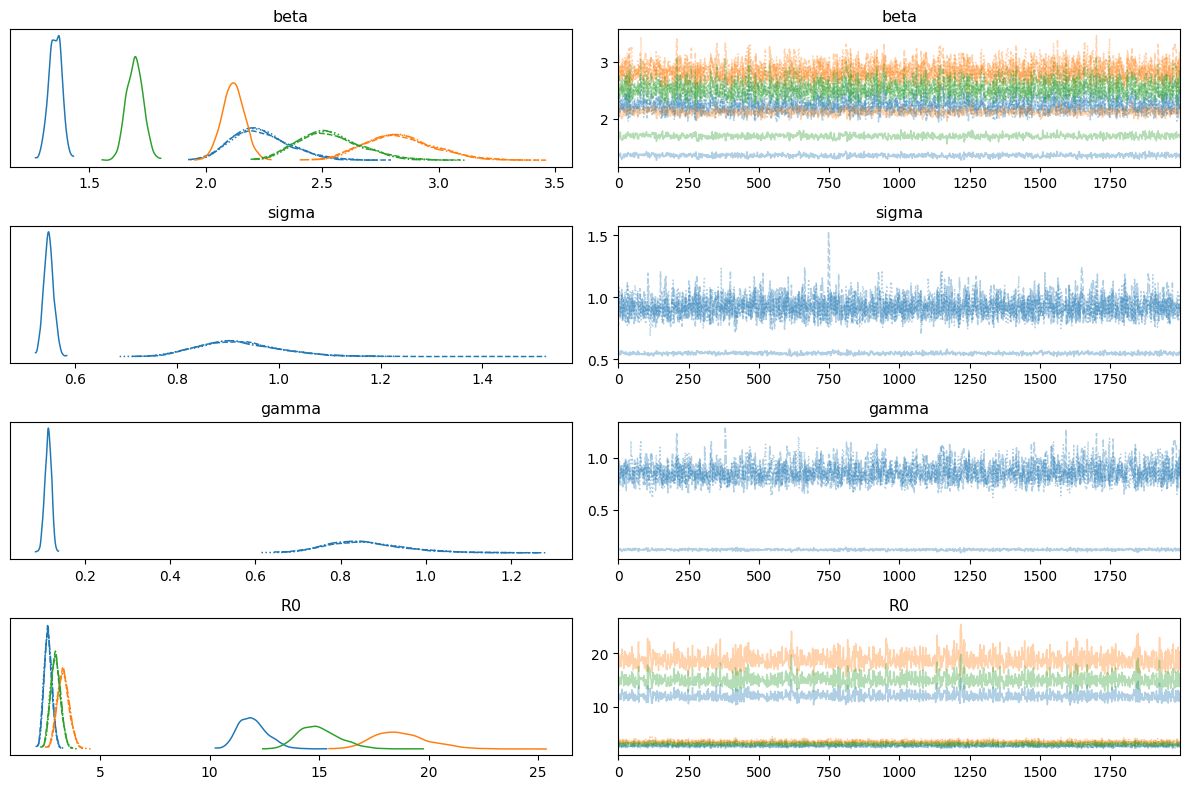

In [76]:
# # Extract posterior samples
# post_no = fit_multi_model.draws_pd()

# ## save the posterior samples
# post_no.to_csv('./Data/posterior_samples_no_coupling.csv', index=False)
az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

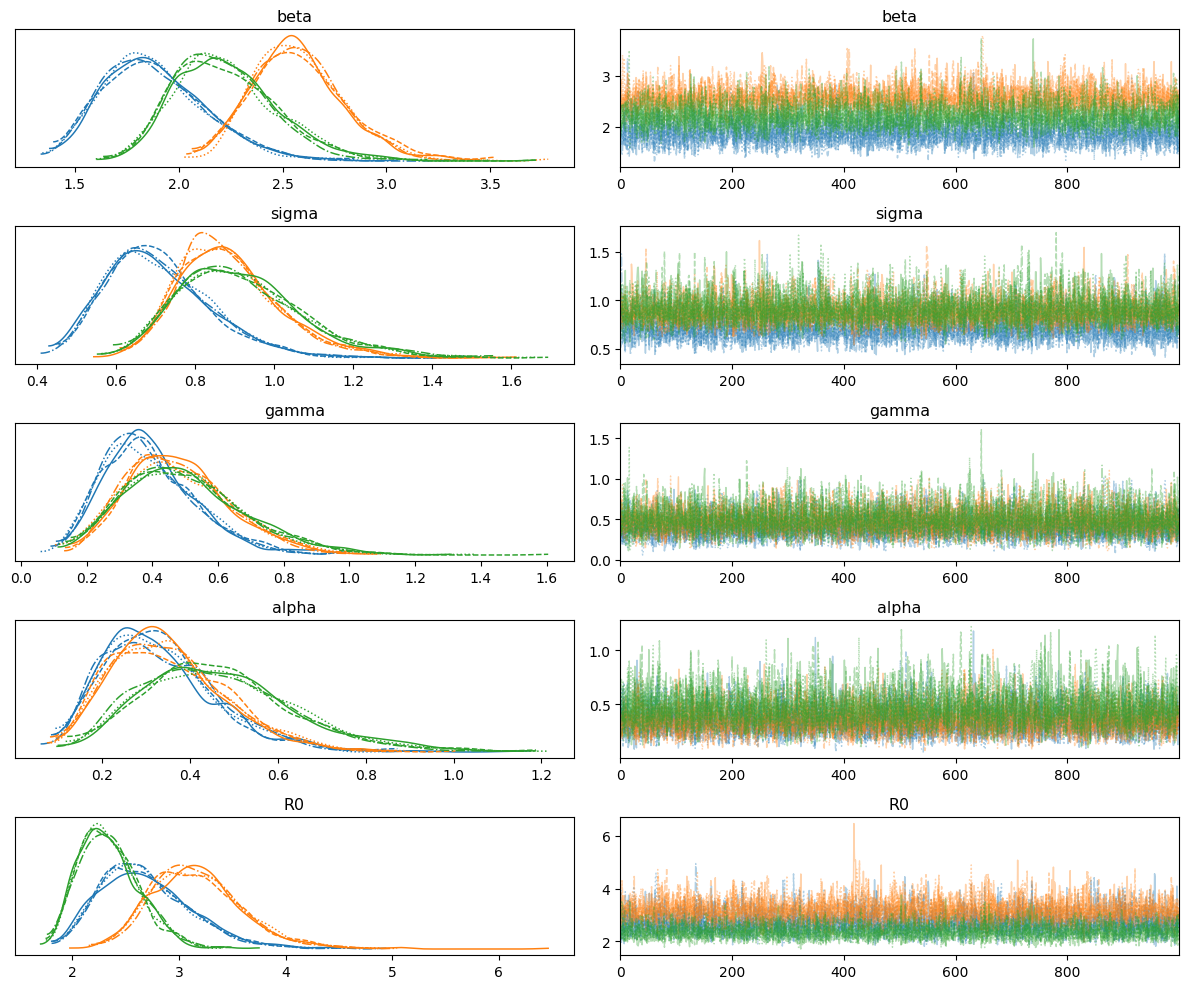

In [ ]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [77]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = (1/8.5)*7 #incubation rate per week
gamma = (1/13)*7    # 1/infectious period (Ebola: ~7 days)

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

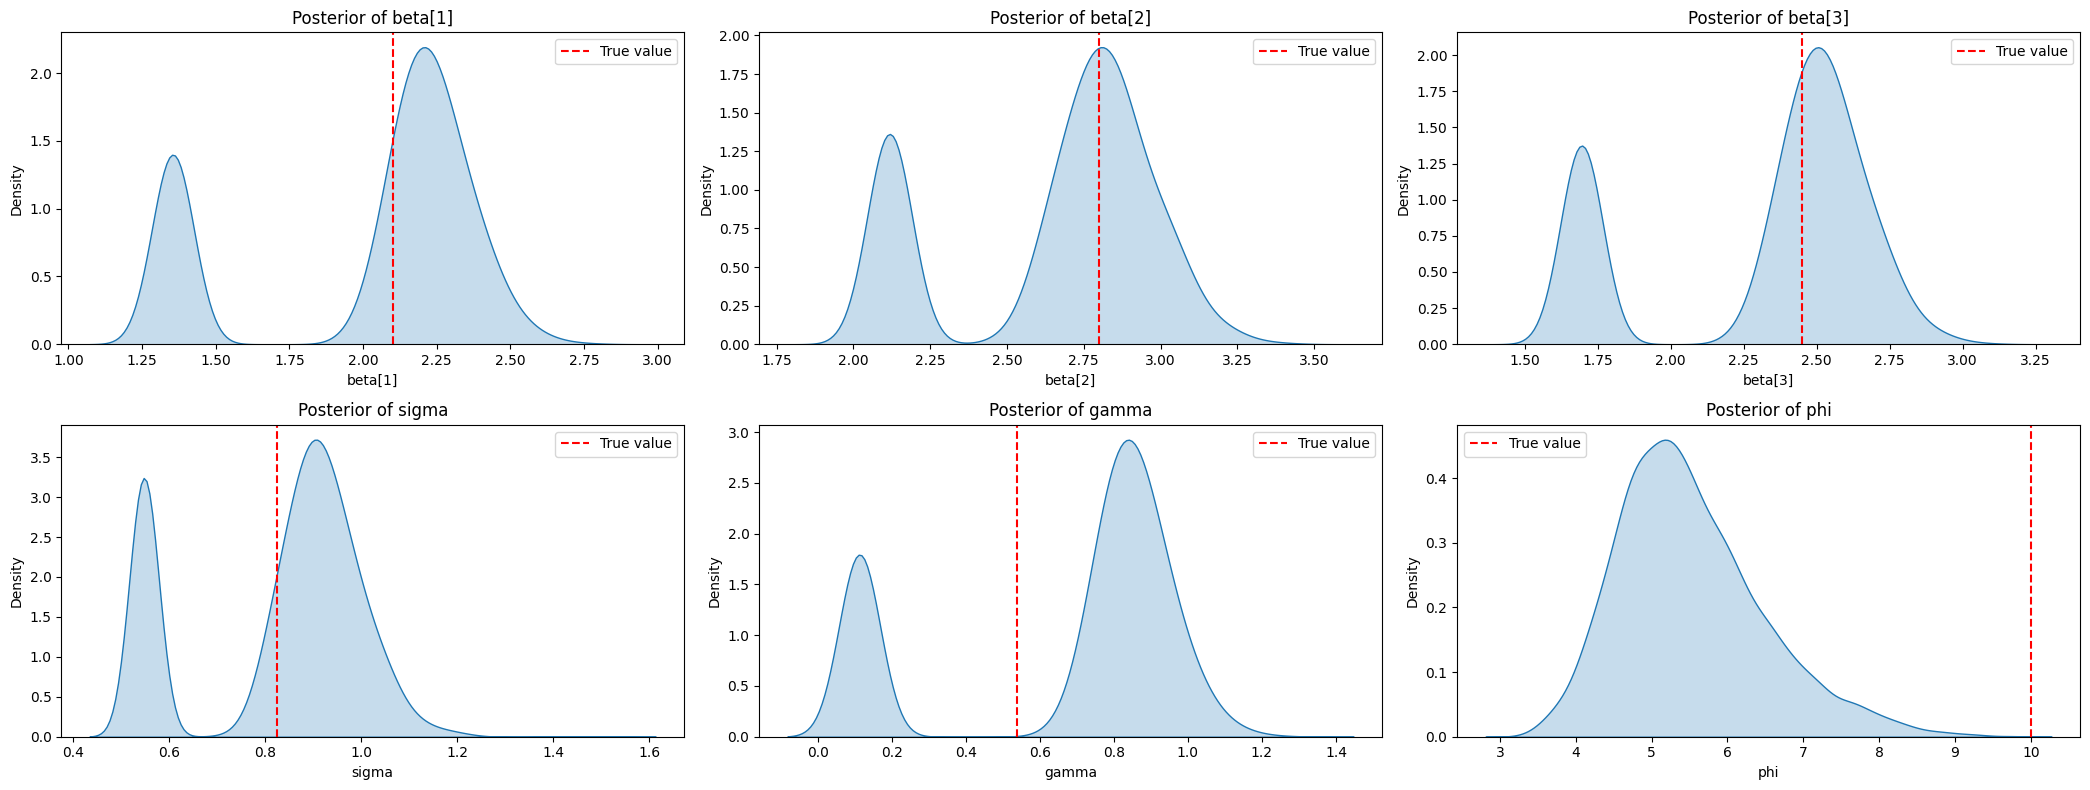

In [78]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
                "sigma","gamma", 'phi']
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma': sigma, 'gamma': gamma,
    'phi': phi , 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t)

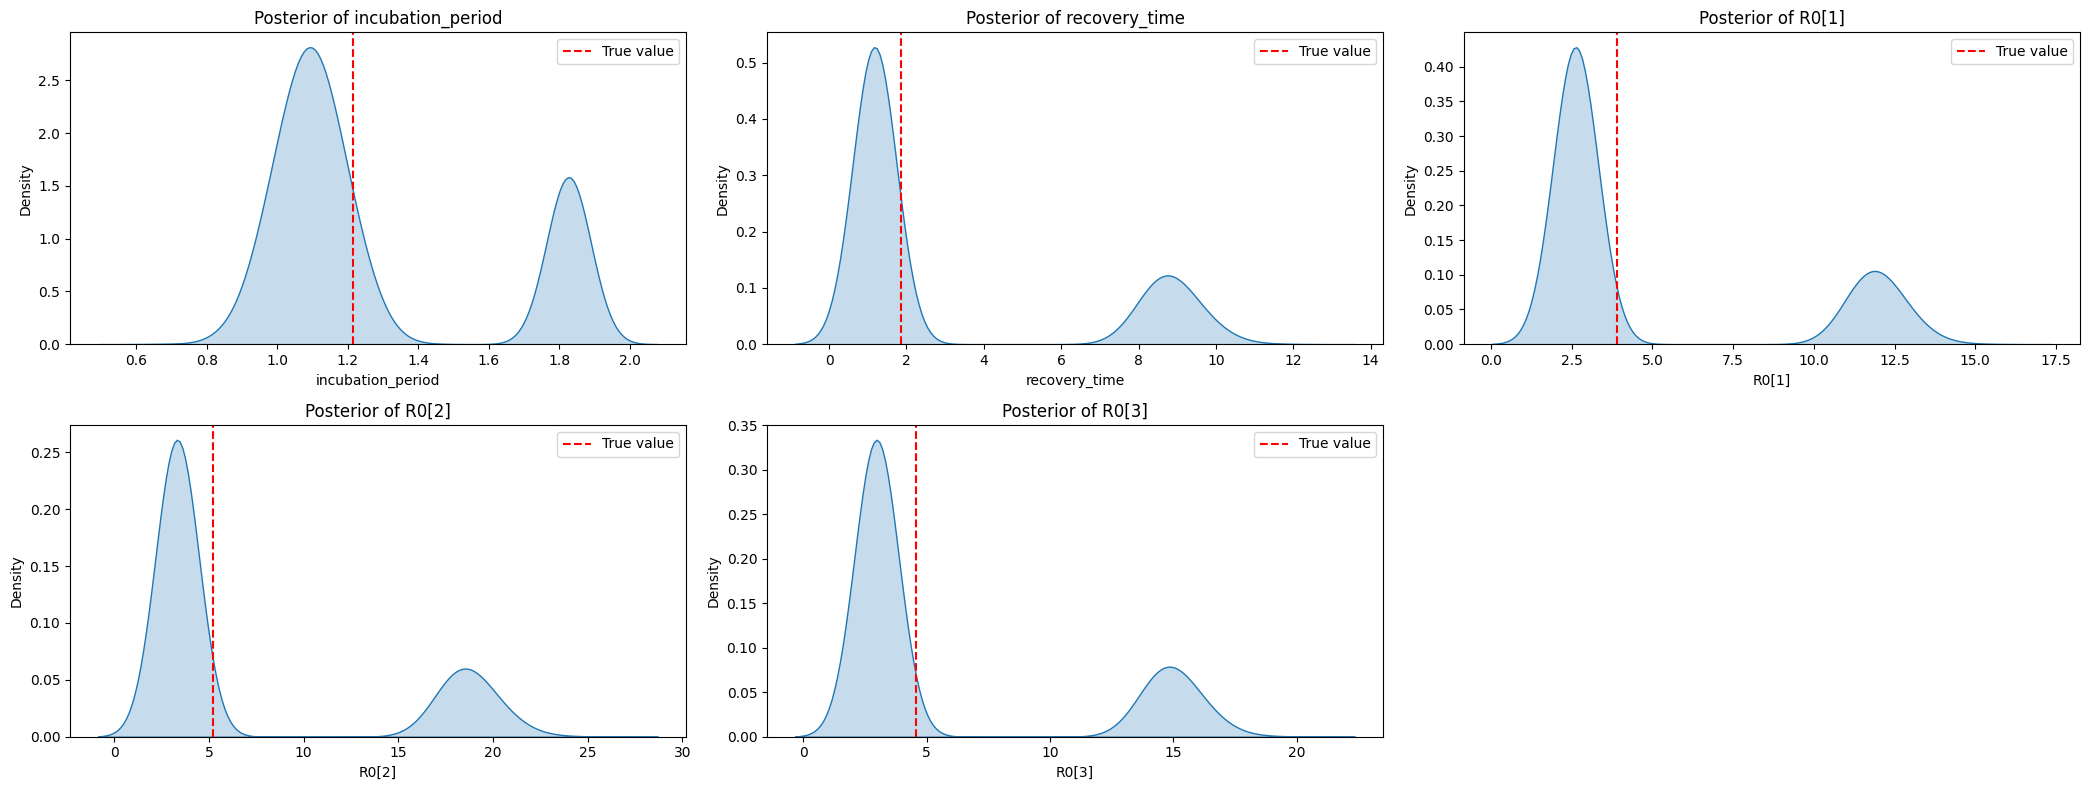

In [79]:
parameters1 = ["incubation_period","recovery_time",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time':rec,
    'incubation_period': incu}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1)

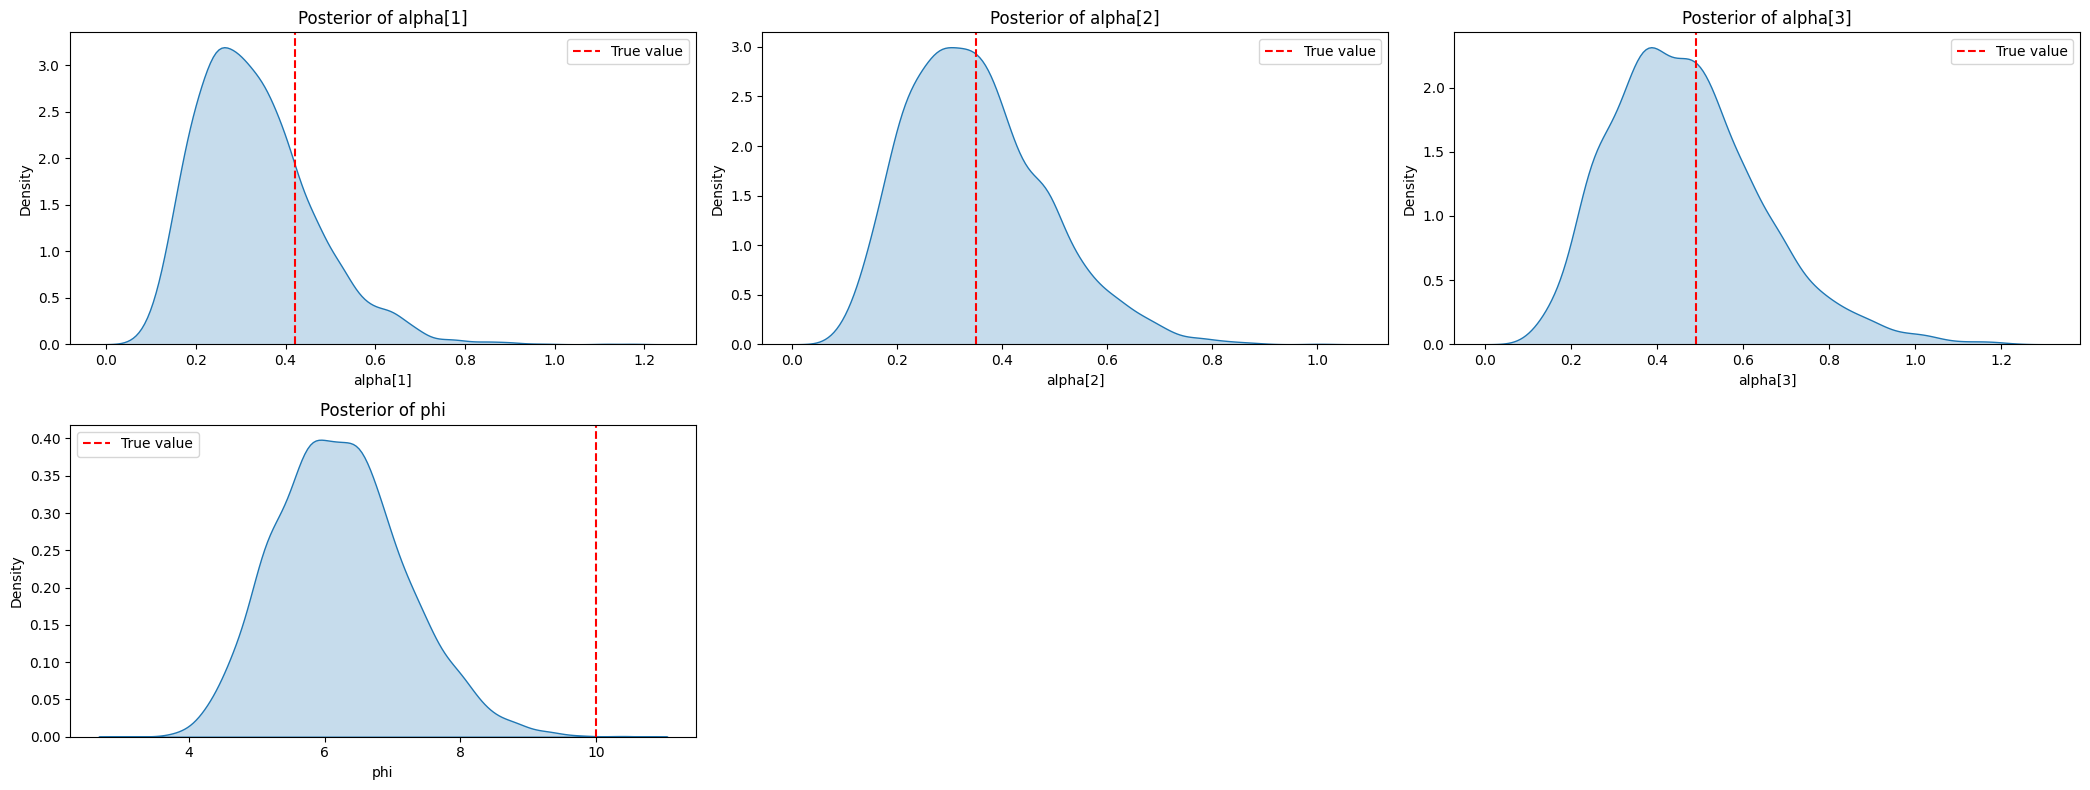

In [ ]:
parameters1 = ['phi']
t1 = {'phi': phi}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_alphaPhi')

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▉         | 00:18 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:41 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 02:10 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:14 Iteration:  300 / 2000 [ 15%]  (Warmup)




















chain 1 |██▋       | 08:19 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 08:22 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 08:27 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 08:42 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 08:44 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 08:56 Iteration: 1000 / 2000 [ 50%]  (Warmup)

chain 1 |████████▏ | 09:34 Iteration: 1500 / 2000 [ 75%]  (Sampling)

chain 1 |████████▋ | 09:40 Iteration: 1600 / 2000 [ 80%]  (Sampling)

chain 1 |█████████ | 09:55 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |█████████▌| 09:58 Iteration: 1800 / 2000 [ 90%

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


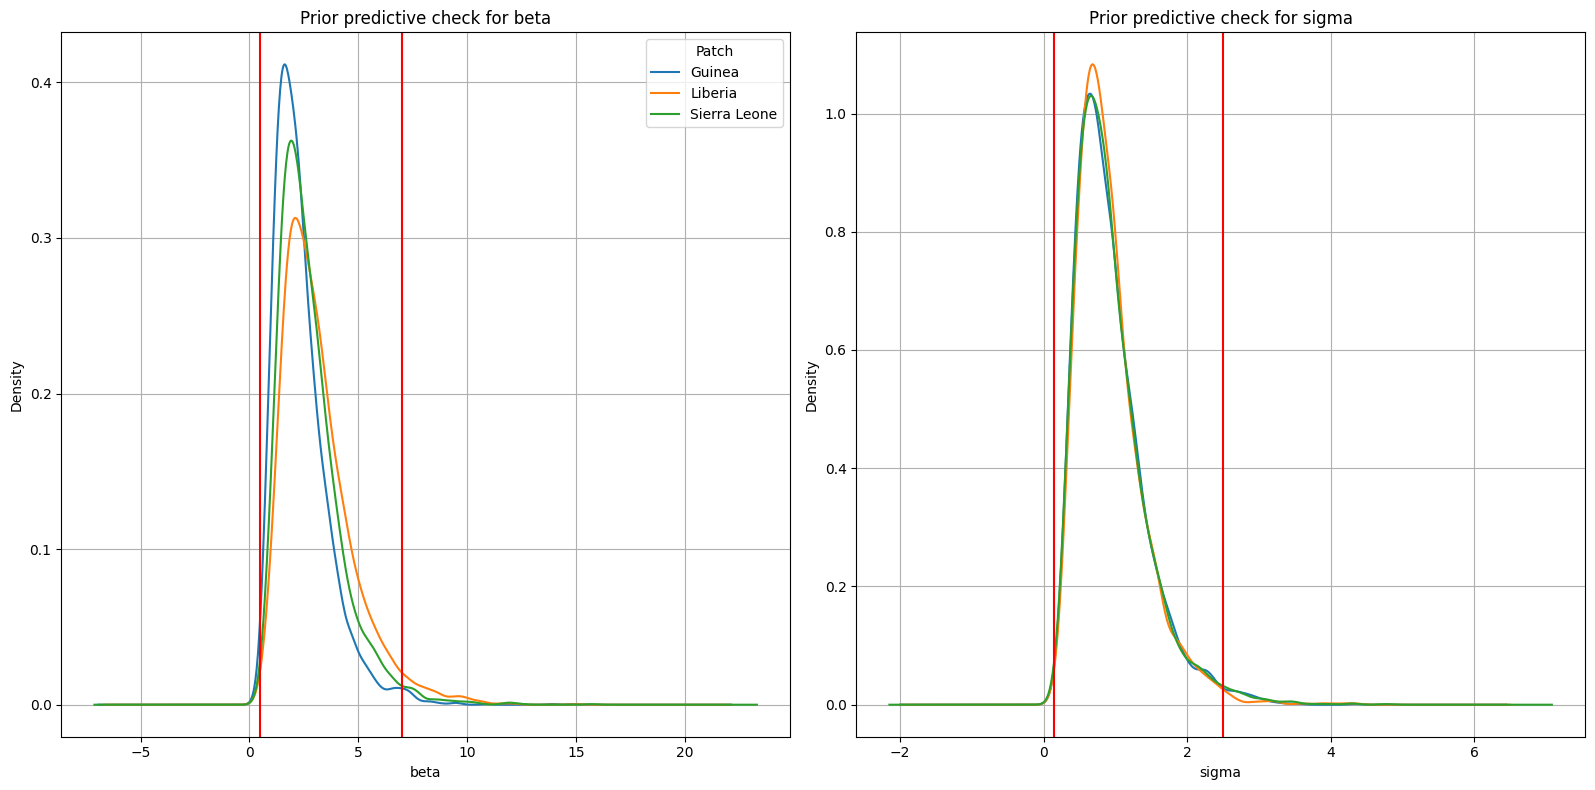

In [ ]:
params = ['beta','sigma', 'gamma']
boundaries = [0.5, 7, 0.14, 2.5, 0.1, 2.0]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()